# Ungraded Lab: Intro to Keras Tuner

Developing machine learning models is usually an iterative process. You start with an initial design then reconfigure until you get a model that can be trained efficiently in terms of time and compute resources. As you may already know, these settings that you adjust are called _hyperparameters_. These are the variables that govern the training process and the topology of an ML model. These remain constant over the training process and directly impact the performance of your ML program.

The process of finding the optimal set of hyperparameters is called *hyperparameter tuning* or *hypertuning*, and it is an essential part of a machine learning pipeline. Without it, you might end up with a model that has unnecessary parameters and take too long to train.

Hyperparameters are of two types:
1. *Model hyperparameters* which influence model selection such as the number and width of hidden layers

2. *Algorithm hyperparameters* which influence the speed and quality of the learning algorithm such as the learning rate for Stochastic Gradient Descent (SGD) and the number of nearest neighbors for a k Nearest Neighbors (KNN) classifier.

For more complex models, the number of hyperparameters can increase dramatically and tuning them manually can be quite challenging.

In this lab, you will practice hyperparameter tuning with [Keras Tuner](https://keras-team.github.io/keras-tuner/), a package from the Keras team that automates this process. For comparison, you will first train a baseline model with pre-selected hyperparameters, then redo the process with tuned hyperparameters. Some of the examples and discussions here are taken from the [official tutorial provided by Tensorflow](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/keras/keras_tuner.ipynb#scrollTo=sKwLOzKpFGAj) but we've expounded on a few key parts for clarity.

Let's begin!

**Note: The notebooks in this course are shared with read-only access. To be able to save your work, kindly select File > Save a Copy in Drive from the Colab menu and run the notebook from there. You will need a Gmail account to save a copy.**

## Download and prepare the dataset

Let us first load the [Fashion MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) into your workspace. You will use this to train a machine learning model that classifies images of clothing.

## Import Required Libraries

This section imports TensorFlow, Keras components, Keras Tuner for hyperparameter optimization, and visualization tools such as Matplotlib and Seaborn. These libraries are required for model development, tuning, training, and evaluation.


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


## Load and Preprocess the MNIST Dataset

The MNIST handwritten digits dataset is loaded and normalized. The images are reshaped to include a channel dimension so the model can optionally use convolutional layers. This dataset replaces the Fashion-MNIST dataset used in the original notebook.


In [2]:
(img_train, label_train), (img_test, label_test) = keras.datasets.mnist.load_data()

# Normalize + reshape
img_train = img_train.reshape(-1, 28, 28, 1) / 255.0
img_test = img_test.reshape(-1, 28, 28, 1) / 255.0

print("Training samples:", img_train.shape)
print("Test samples:", img_test.shape)


11490434/11490434 [==============================] - 35s 3us/step
Training samples: (60000, 28, 28, 1)
Test samples: (10000, 28, 28, 1)


## Data Augmentation Setup

A data augmentation pipeline is created to introduce controlled randomness in the training dataset. This includes random rotations, translations, and zooming. Augmentation helps improve model robustness and reduces overfitting.


In [3]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])


## Define the HyperModel for Keras Tuner

This function defines the model architecture to be used by Keras Tuner.
Major modifications include:

- A hyperparameter (`use_cnn`) that switches between a CNN-based architecture and a traditional MLP.
- Tunable dense layer size using Keras Tuner's integer search space.
- GELU activation function in place of ReLU.
- BatchNormalization and Dropout layers added for improved generalization.
- A tunable learning rate for the Adam optimizer.

This design allows the tuner to explore both shallow and deeper model structures.


In [4]:
def build_model(hp):
    model = keras.Sequential()

    # Hyperparameter to choose CNN or MLP
    use_cnn = hp.Boolean("use_cnn")

    if use_cnn:
        model.add(layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)))
        model.add(layers.MaxPooling2D())
        model.add(layers.Conv2D(64, (3,3), activation="relu"))
        model.add(layers.MaxPooling2D())
        model.add(layers.Flatten())
    else:
        model.add(layers.Flatten(input_shape=(28,28,1)))

    # Tunable dense layer
    hp_units = hp.Int("units", min_value=32, max_value=256, step=32)
    model.add(layers.Dense(hp_units, activation="gelu"))

    # Added extra enhancements
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    # Output layer
    model.add(layers.Dense(10, activation="softmax"))

    # Tunable learning rate
    hp_lr = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


Hyperparameter Tuning Using RandomSearch

In the original notebook, Hyperband was used for hyperparameter tuning.
However, Hyperband can be slow on CPU-based systems due to multiple brackets and repeated training rounds.

To improve performance and reduce total runtime, I replaced Hyperband with RandomSearch from Keras Tuner.
RandomSearch allows explicit control of the number of trials and provides a predictable and faster tuning process.

In [6]:
# Faster hyperparameter tuning using RandomSearch instead of Hyperband

tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=8,      # number of trials you want (can change to 5, 6, 10, etc.)
    directory="ktuner_results",
    project_name="mnist_fast_search"
)

tuner.search(
    data_augmentation(img_train),
    label_train,
    epochs=8,          # can increase to 10 or 12 if fast enough
    validation_split=0.2
)

best_hps = tuner.get_best_hyperparameters(1)[0]
model = tuner.hypermodel.build(best_hps)


Trial 8 Complete [00h 04m 02s]
val_accuracy: 0.9682499766349792

Best val_accuracy So Far: 0.9770833253860474
Total elapsed time: 00h 21m 26s


## Train the Best Model with EarlyStopping

After selecting the best hyperparameters, the model is rebuilt and trained.
An EarlyStopping callback is added to:

- Monitor validation loss
- Stop training when improvement stalls
- Restore the weights from the epoch with the best validation performance

This prevents overfitting and reduces unnecessary training time.


In [7]:
model = tuner.hypermodel.build(best_hps)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    img_train,
    label_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stopping]
)


Epoch 1/10
1500/1500 [==============================] - 43s 26ms/step - loss: 0.1132 - accuracy: 0.9649 - val_loss: 0.0760 - val_accuracy: 0.9796
Epoch 2/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0519 - accuracy: 0.9835 - val_loss: 0.0463 - val_accuracy: 0.9854
Epoch 3/10
1500/1500 [==============================] - 31s 21ms/step - loss: 0.0385 - accuracy: 0.9877 - val_loss: 0.0371 - val_accuracy: 0.9896
Epoch 4/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0313 - accuracy: 0.9901 - val_loss: 0.0438 - val_accuracy: 0.9873
Epoch 5/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0248 - accuracy: 0.9915 - val_loss: 0.0310 - val_accuracy: 0.9909
Epoch 6/10
1500/1500 [==============================] - 36s 24ms/step - loss: 0.0189 - accuracy: 0.9941 - val_loss: 0.0350 - val_accuracy: 0.9897
Epoch 7/10
1500/1500 [==============================] - 40s 27ms/step - loss: 0.0182 - accuracy: 0.9942 - val_loss: 0.0435 -

## Evaluate the Tuned Model on the Test Dataset

The trained model is evaluated using the MNIST test dataset.
The final accuracy score is printed. This provides an unbiased estimate of the model's performance after hyperparameter tuning.


In [8]:
test_loss, test_acc = model.evaluate(img_test, label_test)
print("Test Accuracy:", test_acc)


313/313 [==============================] - 3s 8ms/step - loss: 0.0292 - accuracy: 0.9913
Test Accuracy: 0.9912999868392944


## Plot Training and Validation Accuracy

This section visualizes how the model's training and validation accuracy evolve across epochs. 
These curves help identify:

- Underfitting or overfitting behavior
- Quality of convergence
- Stability of training


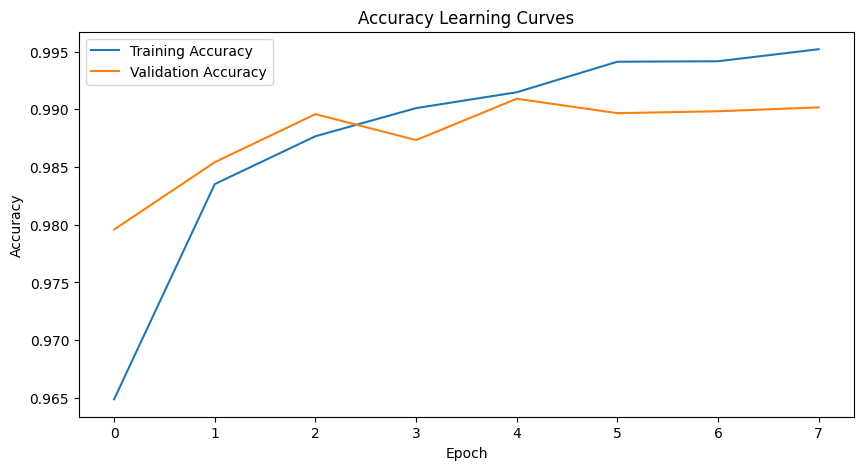

In [9]:
plt.figure(figsize=(10,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## Plot Training and Validation Loss

Loss curves are plotted to complement the accuracy curves.
Together, these graphs provide insights into model optimization behavior and whether the model generalizes well.


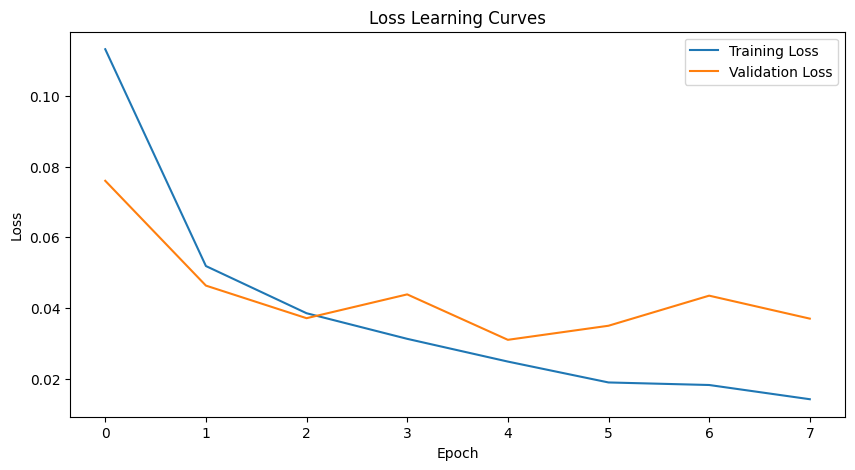

In [10]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Confusion Matrix for Model Evaluation

A confusion matrix is generated using the test dataset to provide a detailed breakdown of correct and incorrect predictions for each class.
This offers a deeper understanding of model performance beyond a single accuracy value.


313/313 [==============================] - 3s 7ms/step


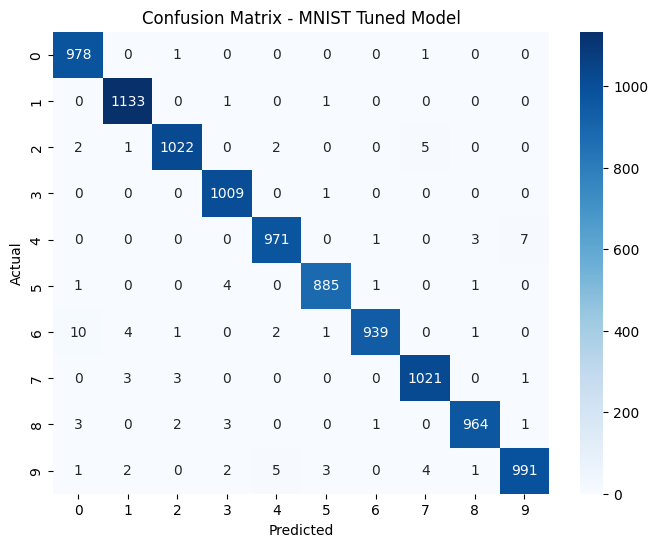

In [11]:
predictions = model.predict(img_test).argmax(axis=1)

cm = confusion_matrix(label_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - MNIST Tuned Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Save the Final Trained Model

The trained model is saved to disk in HDF5 format. 
This allows the model to be reused later for inference or further analysis without retraining.


In [12]:
model.save("mnist_tuned_model.h5")
print("Model saved as mnist_tuned_model.h5")


Model saved as mnist_tuned_model.h5


C:\Users\Nitya\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
